In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [ ]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [ ]:
df["Country"].nunique()

38

In [ ]:
df["Quantity"] < 0

,Quantity
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


In [ ]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
len(df[df["Quantity"] < 0])

10624

In [ ]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [ ]:
negative_qty = df[df["Quantity"] < 0]

In [ ]:
len(negative_qty)

10624

In [ ]:
negative_qty["InvoiceNo"].astype(str).str.startswith("C")

,InvoiceNo
141,True
154,True
235,True
236,True
237,True
...,...
540449,True
541541,True
541715,True
541716,True


In [ ]:
negative_qty["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [ ]:
non_cancel_negative = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

In [ ]:
non_cancel_negative.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [ ]:
#Normal sale → positive quantity, usually positive price
#Cancellation/return → InvoiceNo starts with C, typically negative quantity
#Internal adjustment/non-sale → negative quantity, no C, zero price, blank description/customer

In [ ]:
non_cancel_positive = df[
    (df["Quantity"] > 0) &
    (df["InvoiceNo"].astype(str).str.startswith("C"))
]

In [ ]:
len(non_cancel_positive)

0

In [ ]:
non_cancel_positive["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [ ]:
#There are 0 records where invoiceno starts with c and the quantity is positve indicating that c prefix is a reliable indicator of a cancellation within this dataset

In [ ]:
zero_price_positive = df[
    (df["UnitPrice"] == 0) &
    (df["Quantity"] > 0)
]

In [ ]:
zero_price_positive.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.0,NaN,United Kingdom


In [ ]:
len(zero_price_positive)

1179

In [ ]:
zero_price = df[df["UnitPrice"] == 0]

In [ ]:
zero_price["Description"].isna().sum()

np.int64(1454)

In [ ]:
zero_price["Quantity"].describe()

,Quantity
count,2515.000000
mean,-53.421074
std,540.206783
min,-9600.000000
25%,-32.000000
50%,-1.000000
75%,3.000000
max,12540.000000


In [ ]:
zero_price["CustomerID"].isna().sum()

np.int64(2475)

In [ ]:
# 1454 have missing description and 2475 have missing customer id meaning about 98 percent of the 2515 zero price records are missing customerid meaning that these are mostly internal/non customer transactions, not ordinary sales.

In [ ]:
negative_price = df[
    df["UnitPrice"] < 0
]

In [ ]:
negative_price

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
len(negative_price)

2

In [ ]:
clean_df = df.copy()

In [ ]:
clean_df.shape

(541909, 8)

In [ ]:
clean_df = clean_df.drop_duplicates()

In [ ]:
clean_df.shape

(536641, 8)

In [ ]:
#drops all exact duplicates

In [ ]:
clean_df.duplicated().sum()

np.int64(0)

In [ ]:
import numpy as np

In [ ]:
conditions = [
    clean_df["InvoiceNo"].astype(str).str.startswith("C"),

    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
]

In [ ]:
choices = [
    "Cancellation",
    "Sale"
]

In [ ]:
clean_df["TransactionType"] = np.select(
    conditions,
    choices,
    default="Internal/Adjustment"
)

In [ ]:
clean_df["TransactionType"].value_counts()

,count
TransactionType,
Sale,524878
Cancellation,9251
Internal/Adjustment,2512


In [ ]:
clean_df[
    clean_df["TransactionType"] == "Sale"
].sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
341983,566788,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,120,2011-09-15 10:31:00,2.10,14306.0,United Kingdom,Sale
285728,561922,82486,WOOD S/3 CABINET ANT WHITE FINISH,2,2011-08-01 12:12:00,8.95,13167.0,United Kingdom,Sale
267923,560368,48194,DOORMAT HEARTS,2,2011-07-18 12:25:00,7.95,17841.0,United Kingdom,Sale
273590,560841,40001,WHITE BAMBOO RIBS LAMPSHADE,24,2011-07-21 12:25:00,0.64,14298.0,United Kingdom,Sale
384337,570116,21484,CHICK GREY HOT WATER BOTTLE,1,2011-10-07 12:38:00,4.25,12856.0,United Kingdom,Sale
223089,556473,20665,RED RETROSPOT PURSE,2,2011-06-12 12:00:00,2.95,17265.0,United Kingdom,Sale
168724,551136,85054,FRENCH ENAMEL POT W LID,6,2011-04-26 13:05:00,2.95,15301.0,United Kingdom,Sale
318609,564837,22847,BREAD BIN DINER STYLE IVORY,1,2011-08-30 12:40:00,33.29,NaN,United Kingdom,Sale
538412,581405,21439,BASKET OF TOADSTOOLS,1,2011-12-08 13:50:00,1.25,13521.0,United Kingdom,Sale
195142,553702,22907,PACK OF 20 NAPKINS PANTRY DESIGN,3,2011-05-18 14:50:00,0.85,13263.0,United Kingdom,Sale


In [ ]:
clean_df[
    clean_df["TransactionType"] == "Cancellation"
].sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
336550,C566384,21588,RETROSPOT GIANT TUBE MATCHES,-1,2011-09-12 12:41:00,2.55,17811.0,United Kingdom,Cancellation
384034,C570099,21928,JUMBO BAG SCANDINAVIAN BLUE PAISLEY,-1,2011-10-07 12:11:00,1.65,13798.0,United Kingdom,Cancellation
252281,C559105,23202,JUMBO BAG VINTAGE LEAF,-1,2011-07-06 11:10:00,2.08,16393.0,United Kingdom,Cancellation
327643,C565681,22332,SKULLS PARTY BAG + STICKER SET,-8,2011-09-06 10:42:00,1.65,15521.0,United Kingdom,Cancellation
4907,C536820,21843,RED RETROSPOT CAKE STAND,-1,2010-12-02 17:14:00,10.95,18168.0,United Kingdom,Cancellation
400583,C571319,23145,ZINC T-LIGHT HOLDER STAR LARGE,-1,2011-10-17 10:50:00,0.95,17164.0,United Kingdom,Cancellation
168290,C551015,22361,GLASS JAR DAISY FRESH COTTON WOOL,-1,2011-04-26 11:06:00,2.55,12753.0,Japan,Cancellation
410571,C572112,84406B,CREAM CUPID HEARTS COAT HANGER,-1,2011-10-20 19:13:00,3.75,14113.0,United Kingdom,Cancellation
72927,C542273,20980,36 PENCILS TUBE POSY,-9,2011-01-27 10:01:00,1.25,12578.0,Italy,Cancellation
321203,C565140,22326,ROUND SNACK BOXES SET OF4 WOODLAND,-1,2011-09-01 12:56:00,2.95,17841.0,United Kingdom,Cancellation


In [ ]:
clean_df[
    clean_df["TransactionType"] == "Internal/Adjustment"
].sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType
205714,554830,21904,NaN,3,2011-05-26 15:22:00,0.0,NaN,United Kingdom,Internal/Adjustment
14371,537534,22109,FULL ENGLISH BREAKFAST PLATE,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom,Internal/Adjustment
242412,558340,22692,DOORMAT WELCOME TO OUR HOME,1,2011-06-28 14:01:00,0.0,NaN,United Kingdom,Internal/Adjustment
75252,542569,85028L,NaN,-1,2011-01-28 14:53:00,0.0,NaN,United Kingdom,Internal/Adjustment
124020,546933,21556,CERAMIC STRAWBERRY MONEY BOX,2,2011-03-18 11:02:00,0.0,NaN,United Kingdom,Internal/Adjustment
94304,544346,22114,NaN,-21,2011-02-18 09:50:00,0.0,NaN,United Kingdom,Internal/Adjustment
41094,539750,21481,FAWN BLUE HOT WATER BOTTLE,1,2010-12-21 15:40:00,0.0,NaN,United Kingdom,Internal/Adjustment
147826,549149,35649,NaN,-43,2011-04-06 15:31:00,0.0,NaN,United Kingdom,Internal/Adjustment
340683,566712,22030,??,-635,2011-09-14 12:04:00,0.0,NaN,United Kingdom,Internal/Adjustment
344384,567059,22452,NaN,-63,2011-09-16 11:41:00,0.0,NaN,United Kingdom,Internal/Adjustment


In [ ]:
#each condition seems to be correct

In [ ]:
sales_df = clean_df[
    clean_df["TransactionType"] == "Sale"
]

In [ ]:
sales_df["Description"].isna().sum()

np.int64(0)

In [ ]:
sales_df["CustomerID"].isna().sum()

np.int64(132186)

In [ ]:
(sales_df["UnitPrice"] <= 0).sum()

np.int64(0)

In [ ]:
(sales_df["Quantity"] <= 0).sum()

np.int64(0)

In [ ]:
sales_df = clean_df[
    clean_df["TransactionType"] == "Sale"
].copy()

In [ ]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [ ]:
sales_df[
    ["InvoiceNo", "Description", "Quantity", "UnitPrice", "Revenue"]
].head(10)

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34
5,536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,15.30
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50
7,536366,HAND WARMER UNION JACK,6,1.85,11.10
8,536366,HAND WARMER RED POLKA DOT,6,1.85,11.10
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,54.08


In [ ]:
sales_df["Revenue"].sum()

np.float64(10642110.804)

In [ ]:
sales_df["Revenue"].describe()

,Revenue
count,524878.000000
mean,20.275399
std,271.693566
min,0.001000
25%,3.900000
50%,9.920000
75%,17.700000
max,168469.600000


In [ ]:
#gross sales revenue = £10,642,110.80 across 524,878 sales line items

In [ ]:
sales_df.nlargest(
    10, "Revenue"
)[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country", "Revenue"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,NaN,United Kingdom,13541.33
299982,A563185,B,Adjust bad debt,1,11062.06,NaN,United Kingdom,11062.06
173382,551697,POST,POSTAGE,1,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,17450.0,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,14646.0,Netherlands,4992.00


In [ ]:
#first sale rule is too broad

In [ ]:
sales_df["StockCode"].value_counts().head(30)

,count
StockCode,
85123A,2253
85099B,2109
22423,2007
47566,1699
20725,1582
84879,1476
22197,1418
22720,1392
21212,1352


In [ ]:
clean_df[
    clean_df["Description"].astype(str).str.contains(
        "AMAZON FEE|Adjust bad debt",
        case=False
    )
][
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID",
     "TransactionType"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,TransactionType
14514,C537600,AMAZONFEE,AMAZON FEE,-1,1.00,NaN,Cancellation
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33,NaN,Cancellation
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,NaN,Sale
16232,C537644,AMAZONFEE,AMAZON FEE,-1,13474.79,NaN,Cancellation
16313,C537647,AMAZONFEE,AMAZON FEE,-1,5519.25,NaN,Cancellation
16356,C537651,AMAZONFEE,AMAZON FEE,-1,13541.33,NaN,Cancellation
16357,C537652,AMAZONFEE,AMAZON FEE,-1,6706.71,NaN,Cancellation
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02,NaN,Cancellation
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71,NaN,Cancellation
96844,C544587,AMAZONFEE,AMAZON FEE,-1,5575.28,NaN,Cancellation


In [ ]:
special_codes = clean_df[
    clean_df["StockCode"].astype(str).str.fullmatch(r"[A-Za-z]+")
]

special_codes["StockCode"].value_counts()

,count
StockCode,
POST,1256
DOT,710
M,566
D,77
S,62
AMAZONFEE,34
CRUK,16
DCGSSGIRL,13
DCGSSBOY,11


In [ ]:
special_codes[
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
14514,AMAZONFEE,AMAZON FEE
299982,B,Adjust bad debt
317508,CRUK,CRUK Commission
141,D,Discount
84016,DCGSSBOY,BOYS PARTY BAG
84017,DCGSSGIRL,GIRLS PARTY BAG
1814,DOT,DOTCOM POSTAGE
136537,DOT,NaN
2239,M,Manual
157195,PADS,PADS TO MATCH ALL CUSHIONS


In [ ]:
special_sales = sales_df[
    sales_df["StockCode"].astype(str).str.fullmatch(r"[A-Za-z]+")
]

special_sales["StockCode"].value_counts()

,count
StockCode,
POST,1126
DOT,706
M,316
DCGSSGIRL,13
DCGSSBOY,11
PADS,3
S,2
AMAZONFEE,2
m,1


In [ ]:
special_sales.groupby(
    ["StockCode", "Description"],
    dropna=False
).agg(
    Rows=("InvoiceNo", "count"),
    TotalQuantity=("Quantity", "sum"),
    TotalRevenue=("Revenue", "sum")
).sort_values("TotalRevenue", ascending=False)

,,Rows,TotalQuantity,TotalRevenue
StockCode,Description,,,
DOT,DOTCOM POSTAGE,706,706,206248.770
POST,POSTAGE,1126,3150,78101.880
M,Manual,316,6984,77750.270
AMAZONFEE,AMAZON FEE,2,2,13761.090
B,Adjust bad debt,1,1,11062.060
DCGSSBOY,BOYS PARTY BAG,11,47,150.550
DCGSSGIRL,GIRLS PARTY BAG,13,47,144.430
S,SAMPLES,2,2,63.050
m,Manual,1,1,2.550


In [ ]:
manual_sales = sales_df[
    sales_df["StockCode"].astype(str).isin(["M", "m"])
]

manual_sales[
    ["InvoiceNo", "Description", "Quantity",
     "UnitPrice", "CustomerID", "Country", "Revenue"]
].sample(15)

,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Country,Revenue
142316,548568,Manual,1,12.75,14543.0,United Kingdom,12.75
252254,559106,Manual,2,7.95,15889.0,United Kingdom,15.90
12423,537377,Manual,12,0.19,15882.0,United Kingdom,2.28
18184,537804,Manual,12,2.95,12748.0,United Kingdom,35.40
414138,572344,Manual,456,1.50,14607.0,United Kingdom,684.00
34064,539317,Manual,2,3.00,17392.0,United Kingdom,6.00
343000,566927,Manual,1,2033.10,17846.0,United Kingdom,2033.10
168322,551016,Manual,2,1.65,17975.0,United Kingdom,3.30
9575,537208,Manual,4,0.85,15889.0,United Kingdom,3.40
491783,578074,Manual,1,1.25,17590.0,United Kingdom,1.25


In [ ]:
conditions = [ clean_df["StockCode"].astype(str).isin(["DOT", "POST"]), clean_df["StockCode"].astype(str).isin(["AMAZONFEE", "CRUK"]), clean_df["StockCode"].astype(str).isin(["M", "m"]), clean_df["StockCode"].astype(str).isin(["B"]), clean_df["StockCode"].astype(str).isin(["D"]), clean_df["StockCode"].astype(str).isin(["S"]) ]

In [ ]:
choices = [ "Postage", "Fee/Commission", "Manual", "Accounting Adjustment", "Discount", "Sample" ]

In [ ]:
clean_df["ItemType"] = np.select(
    conditions,
    choices,
    default="Product"
)

In [ ]:
clean_df["ItemType"].value_counts()

,count
ItemType,
Product,533916
Postage,1966
Manual,567
Discount,77
Sample,62
Fee/Commission,50
Accounting Adjustment,3


In [ ]:
clean_df.groupby(
    ["ItemType", "StockCode", "Description"],
    dropna=False
).size().sort_values(ascending=False).head(25)

ItemType  StockCode  Description                       
Product   85123A     WHITE HANGING HEART T-LIGHT HOLDER    2290
          22423      REGENCY CAKESTAND 3 TIER              2189
          85099B     JUMBO BAG RED RETROSPOT               2156
          47566      PARTY BUNTING                         1720
          20725      LUNCH BAG RED RETROSPOT               1625
          84879      ASSORTED COLOUR BIRD ORNAMENT         1488
          22720      SET OF 3 CAKE TINS PANTRY DESIGN      1465
          21212      PACK OF 72 RETROSPOT CAKE CASES       1367
          20727      LUNCH BAG  BLACK SKULL.               1323
          22457      NATURAL SLATE HEART CHALKBOARD        1272
Postage   POST       POSTAGE                               1252
Product   22386      JUMBO BAG PINK POLKADOT               1245
          22469      HEART OF WICKER SMALL                 1230
          22960      JAM MAKING SET WITH JARS              1221
          21931      JUMBO STORAGE BAG SUKI                1211
          22086      PAPER CHAIN KIT 50'S CHRISTMAS        1194
          22411      JUMBO SHOPPER VINTAGE RED PAISLEY     1192
          20728      LUNCH BAG CARS BLUE                   1185
          22382      LUNCH BAG SPACEBOY DESIGN             1177
          22961      JAM MAKING SET PRINTED                1177
          22666      RECIPE BOX PANTRY YELLOW DESIGN       1173
          23298      SPOTTY BUNTING                        1168
          22699      ROSES REGENCY TEACUP AND SAUCER       1128
          82482      WOODEN PICTURE FRAME WHITE FINISH     1124
          22383      LUNCH BAG SUKI DESIGN                 1121
dtype: int64

In [ ]:
product_sales_df = clean_df[
    (clean_df["TransactionType"] == "Sale") &
    (clean_df["ItemType"] == "Product")
].copy()

In [ ]:
product_sales_df["Revenue"] = (
    product_sales_df["Quantity"] *
    product_sales_df["UnitPrice"]
)

In [ ]:
product_sales_df.shape

(522724, 11)

In [ ]:
product_sales_df["Revenue"].sum()

np.float64(10255121.134)

In [ ]:
#Data is now all clean and we have much cleaner product to sales dataset

In [ ]:
#Business Question 1: How have revenue and sales volume changed monthly and quarterly?

In [ ]:
product_sales_df["Year"] = product_sales_df["InvoiceDate"].dt.year

product_sales_df["Month"] = product_sales_df["InvoiceDate"].dt.month

product_sales_df["YearMonth"] = product_sales_df["InvoiceDate"].dt.to_period("M")

product_sales_df["Quarter"] = product_sales_df["InvoiceDate"].dt.to_period("Q")

In [ ]:
product_sales_df[
    ["InvoiceDate", "Year", "Month", "YearMonth", "Quarter"]
].head()

,InvoiceDate,Year,Month,YearMonth,Quarter
0,2010-12-01 08:26:00,2010,12,2010-12,2010Q4
1,2010-12-01 08:26:00,2010,12,2010-12,2010Q4
2,2010-12-01 08:26:00,2010,12,2010-12,2010Q4
3,2010-12-01 08:26:00,2010,12,2010-12,2010Q4
4,2010-12-01 08:26:00,2010,12,2010-12,2010Q4


In [ ]:
monthly_sales = product_sales_df.groupby("YearMonth").agg(
    Revenue=("Revenue", "sum"),
    UnitsSold=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique")
).reset_index()

In [ ]:
monthly_sales

,YearMonth,Revenue,UnitsSold,Orders
0,2010-12,776329.950,357542,1552
1,2011-01,670654.460,386746,1082
2,2011-02,508081.540,282635,1093
3,2011-03,690591.840,376198,1440
4,2011-04,515884.661,307665,1236
5,2011-05,740487.330,394668,1669
6,2011-06,738233.990,388141,1525
7,2011-07,688802.671,399303,1452
8,2011-08,724708.160,420709,1340
9,2011-09,1029275.382,568723,1821


In [ ]:
monthly_sales["RevenueGrowthPct"] = (
    monthly_sales["Revenue"].pct_change() * 100
)

In [ ]:
monthly_sales["RevenueGrowthPct"] = (
    monthly_sales["RevenueGrowthPct"].round(2)
)

In [ ]:
monthly_sales

,YearMonth,Revenue,UnitsSold,Orders,RevenueGrowthPct
0,2010-12,776329.950,357542,1552,NaN
1,2011-01,670654.460,386746,1082,-13.61
2,2011-02,508081.540,282635,1093,-24.24
3,2011-03,690591.840,376198,1440,35.92
4,2011-04,515884.661,307665,1236,-25.30
5,2011-05,740487.330,394668,1669,43.54
6,2011-06,738233.990,388141,1525,-0.30
7,2011-07,688802.671,399303,1452,-6.70
8,2011-08,724708.160,420709,1340,5.21
9,2011-09,1029275.382,568723,1821,42.03


In [ ]:
quarterly_sales = product_sales_df.groupby("Quarter").agg(
    Revenue=("Revenue", "sum"),
    UnitsSold=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique")
).reset_index()

In [ ]:
quarterly_sales

,Quarter,Revenue,UnitsSold,Orders
0,2010Q4,776329.950,357542,1552
1,2011Q1,1869327.840,1045579,3615
2,2011Q2,1994605.981,1090474,4430
3,2011Q3,2442786.213,1388735,4613
4,2011Q4,3172071.150,1679244,5577


In [ ]:
#q4 2011 wasnt a complete quarter since data ended 9th of december. cannot treat q4 as directly comparable to the complete quarters. same for 2010 q4

In [ ]:
complete_quarters = quarterly_sales[
    quarterly_sales["Quarter"].isin(["2011Q1", "2011Q2", "2011Q3"])
].copy()

In [ ]:
complete_quarters = quarterly_sales[
    quarterly_sales["Quarter"].isin([
        pd.Period("2011Q1"),
        pd.Period("2011Q2"),
        pd.Period("2011Q3")
    ])
].copy()

In [ ]:
complete_quarters

,Quarter,Revenue,UnitsSold,Orders
1,2011Q1,1869327.840,1045579,3615
2,2011Q2,1994605.981,1090474,4430
3,2011Q3,2442786.213,1388735,4613


In [ ]:
complete_quarters["RevenueGrowthPct"] = (
    complete_quarters["Revenue"].pct_change() * 100
).round(2)

In [ ]:
complete_quarters

,Quarter,Revenue,UnitsSold,Orders,RevenueGrowthPct
1,2011Q1,1869327.840,1045579,3615,NaN
2,2011Q2,1994605.981,1090474,4430,6.70
3,2011Q3,2442786.213,1388735,4613,22.47


In [ ]:
#visualizing the first business question now

In [ ]:
import matplotlib.pyplot as plt

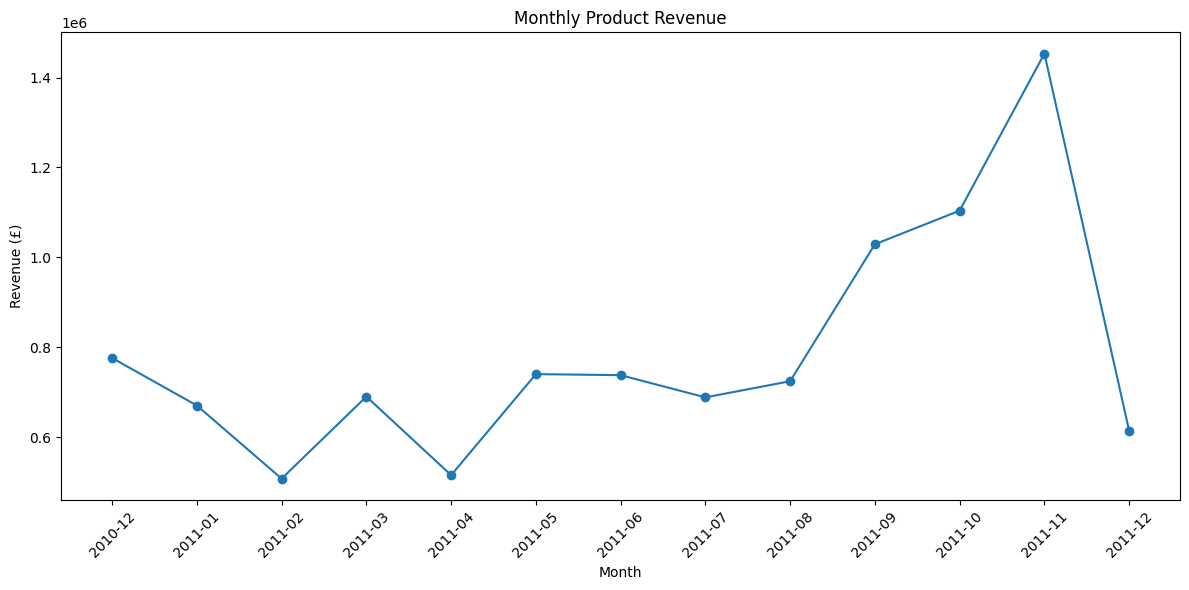

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["YearMonth"].astype(str),
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Product Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Business Question #1: How have revenue and sales volume changed monthly and quarterly?

Product revenue accelerated substantially in late 2011.
Among complete months, November 2011 generated the highest revenue at approximately £1.45M, following £1.03M in September and £1.10M in October.
Among complete quarters, Q3 generated approximately £2.44M in revenue, representing 22.47% growth from Q2. December 2011 should not be directly compared with complete months because the dataset ends on December 9.

In [ ]:
clean_df["LineValue"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

In [ ]:
clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["YearMonth"] = clean_df["InvoiceDate"].dt.to_period("M").astype(str)
clean_df["Quarter"] = clean_df["InvoiceDate"].dt.to_period("Q").astype(str)

In [ ]:
clean_df.shape

(536641, 15)

In [ ]:
clean_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TransactionType', 'ItemType',
       'LineValue', 'Year', 'Month', 'YearMonth', 'Quarter'],
      dtype='object')

In [ ]:
clean_df.to_csv(
    "online_retail_cleaned.csv",
    index=False
)

In [ ]:
import os

os.path.exists("online_retail_cleaned.csv")

True

WE MOVE TO SQL TO ANSWER THE REST OF BUSINESS QUESTIONS

In [ ]:
import sqlite3

conn = sqlite3.connect("online_retail.db")

In [ ]:
clean_df.to_sql(
    "retail_transactions",
    conn,
    if_exists="replace",
    index=False
)

536641

In [ ]:
pd.read_sql("""
SELECT *
FROM retail_transactions
LIMIT 10;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,ItemType,LineValue,Year,Month,YearMonth,Quarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Sale,Product,15.30,2010,12,2010-12,2010Q4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,Product,20.34,2010,12,2010-12,2010Q4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Sale,Product,22.00,2010,12,2010-12,2010Q4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,Product,20.34,2010,12,2010-12,2010Q4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,Product,20.34,2010,12,2010-12,2010Q4
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,Sale,Product,15.30,2010,12,2010-12,2010Q4
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,Sale,Product,25.50,2010,12,2010-12,2010Q4
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,Sale,Product,11.10,2010,12,2010-12,2010Q4
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,Sale,Product,11.10,2010,12,2010-12,2010Q4
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,Sale,Product,54.08,2010,12,2010-12,2010Q4


In [ ]:
pd.read_sql(""" SELECT count(*) as TotalRows FROM retail_transactions; """, conn)

,TotalRows
0,536641


In [ ]:
pd.read_sql(""" SELECT *
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
LIMIT 10;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,ItemType,LineValue,Year,Month,YearMonth,Quarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Sale,Product,15.30,2010,12,2010-12,2010Q4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,Product,20.34,2010,12,2010-12,2010Q4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Sale,Product,22.00,2010,12,2010-12,2010Q4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,Product,20.34,2010,12,2010-12,2010Q4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Sale,Product,20.34,2010,12,2010-12,2010Q4
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,Sale,Product,15.30,2010,12,2010-12,2010Q4
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,Sale,Product,25.50,2010,12,2010-12,2010Q4
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,Sale,Product,11.10,2010,12,2010-12,2010Q4
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,Sale,Product,11.10,2010,12,2010-12,2010Q4
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,Sale,Product,54.08,2010,12,2010-12,2010Q4


In [ ]:
pd.read_sql(""" Select
YearMonth, SUM(LineValue) as Revenue
From retail_transactions
Where TransactionType = 'Sale'
  And ItemType = 'Product'
Group By YearMonth
Order By YearMonth;
""", conn)

,YearMonth,Revenue
0,2010-12,776329.950
1,2011-01,670654.460
2,2011-02,508081.540
3,2011-03,690591.840
4,2011-04,515884.661
5,2011-05,740487.330
6,2011-06,738233.990
7,2011-07,688802.671
8,2011-08,724708.160
9,2011-09,1029275.382


In [ ]:
pd.read_sql(""" Select
YearMonth, SUM(LineValue) as Revenue, SUM(Quantity) as UnitsSold, COUNT(DISTINCT InvoiceNo) as Orders
From retail_transactions
Where TransactionType = 'Sale'
  And ItemType = 'Product'
Group By YearMonth
Order By YearMonth;
""", conn)

,YearMonth,Revenue,UnitsSold,Orders
0,2010-12,776329.950,357542,1552
1,2011-01,670654.460,386746,1082
2,2011-02,508081.540,282635,1093
3,2011-03,690591.840,376198,1440
4,2011-04,515884.661,307665,1236
5,2011-05,740487.330,394668,1669
6,2011-06,738233.990,388141,1525
7,2011-07,688802.671,399303,1452
8,2011-08,724708.160,420709,1340
9,2011-09,1029275.382,568723,1821


In [ ]:
pd.read_sql(""" WITH MonthlySales AS (
  SELECT
    YearMonth,
    SUM(LineValue) AS Revenue,
    SUM(Quantity) AS UnitsSold,
    COUNT(DISTINCT InvoiceNo) AS Orders
  FROM retail_transactions
  WHERE TransactionType = 'Sale' AND ItemType = 'Product'
  GROUP BY YearMonth
)

SELECT YearMonth, Revenue, UnitsSold, Orders,
LAG(Revenue) over (order by YearMonth) as PreviousRevenue
FROM MonthlySales;
""", conn)

,YearMonth,Revenue,UnitsSold,Orders,PreviousRevenue
0,2010-12,776329.950,357542,1552,NaN
1,2011-01,670654.460,386746,1082,776329.950
2,2011-02,508081.540,282635,1093,670654.460
3,2011-03,690591.840,376198,1440,508081.540
4,2011-04,515884.661,307665,1236,690591.840
5,2011-05,740487.330,394668,1669,515884.661
6,2011-06,738233.990,388141,1525,740487.330
7,2011-07,688802.671,399303,1452,738233.990
8,2011-08,724708.160,420709,1340,688802.671
9,2011-09,1029275.382,568723,1821,724708.160


In [ ]:
pd.read_sql(""" WITH MonthlySales AS (
  SELECT
    YearMonth,
    SUM(LineValue) AS Revenue,
    SUM(Quantity) AS UnitsSold,
    COUNT(DISTINCT InvoiceNo) AS Orders
  FROM retail_transactions
  WHERE TransactionType = 'Sale' AND ItemType = 'Product'
  GROUP BY YearMonth
),
MonthlywithPrevious as (select
YearMonth, Revenue, UnitsSold, Orders,
LAG(Revenue) over (order by YearMonth) as PreviousRevenue
FROM MonthlySales
)

select YearMonth, Revenue, UnitsSold, Orders, PreviousRevenue, ROUND(
    (Revenue - PreviousRevenue) / PreviousRevenue * 100,
    2
) AS RevenueGrowthPct
from monthlywithprevious
""", conn)

,YearMonth,Revenue,UnitsSold,Orders,PreviousRevenue,RevenueGrowthPct
0,2010-12,776329.950,357542,1552,NaN,NaN
1,2011-01,670654.460,386746,1082,776329.950,-13.61
2,2011-02,508081.540,282635,1093,670654.460,-24.24
3,2011-03,690591.840,376198,1440,508081.540,35.92
4,2011-04,515884.661,307665,1236,690591.840,-25.30
5,2011-05,740487.330,394668,1669,515884.661,43.54
6,2011-06,738233.990,388141,1525,740487.330,-0.30
7,2011-07,688802.671,399303,1452,738233.990,-6.70
8,2011-08,724708.160,420709,1340,688802.671,5.21
9,2011-09,1029275.382,568723,1821,724708.160,42.03


#Business question 2: Which Products generate the highest and lowest revenue? (Shown below): REGENCY CAKESTAND 3 TIER generated the highest product revenue at approximately £174.2K, selling 13,851 units across 1,988 orders.

PAPER CRAFT, LITTLE BIRDIE generated the second-highest revenue at approximately £168.5K. However, all 80,995 units were associated with a single order, making it a significant sales outlier rather than evidence of consistently high demand.

Other high-revenue products included WHITE HANGING HEART T-LIGHT HOLDER (£104.3K), PARTY BUNTING (£99.4K), and JUMBO BAG RED RETROSPOT (£94.2K).

At the bottom of the revenue ranking, most products generated very little revenue because they appeared in only one or a few orders. Therefore, low total revenue alone should not automatically be interpreted as poor product performance, since limited sales exposure may explain the low totals.

PADS TO MATCH ALL CUSHIONS generated only £0.003 across three units and appears to have a nominal or placeholder price, so it should be treated cautiously when evaluating product performance.

In [ ]:
pd.read_sql("""
select StockCode, Description, SUM(LineValue) as TotalRevenue, Sum(Quantity) as UnitsSold, count(distinct InvoiceNO) as Orders
from retail_transactions
where TransactionType = 'Sale' and ItemType = 'Product'
group by StockCode, Description
order by TotalRevenue desc
limit 10;
""", conn)

,StockCode,Description,TotalRevenue,UnitsSold,Orders
0,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
1,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
3,47566,PARTY BUNTING,99445.23,18283,1685
4,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
6,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
8,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
9,79321,CHILLI LIGHTS,54096.36,10302,661


In [ ]:
#The second product generated £168K from one order containing 80,995 units. may be an outlier

In [ ]:
pd.read_sql("""
select StockCode, Description, SUM(LineValue) as TotalRevenue, Sum(Quantity) as UnitsSold, count(distinct InvoiceNO) as Orders
from retail_transactions
where TransactionType = 'Sale' and ItemType = 'Product'
group by StockCode, Description
order by TotalRevenue asc
limit 10;
""", conn)

,StockCode,Description,TotalRevenue,UnitsSold,Orders
0,PADS,PADS TO MATCH ALL CUSHIONS,0.003,3,3
1,84227,HEN HOUSE W CHICK IN NEST,0.420,1,1
2,23366,SET 12 COLOURING PENCILS DOILEY,0.650,1,1
3,51014c,"FEATHER PEN,COAL BLACK",0.830,1,1
4,21268,VINTAGE BLUE TINSEL REEL,0.840,2,1
5,90084,PINK CRYSTAL GUITAR PHONE CHARM,0.850,1,1
6,84201C,HAPPY BIRTHDAY CARD TEDDY/CAKE,0.950,5,1
7,84206B,CAT WITH SUNGLASSES BLANK CARD,0.950,5,1
8,84990,60 GOLD AND SILVER FAIRY CAKE CASES,1.100,2,2
9,21009,ETCHED GLASS STAR TREE DECORATION,1.250,1,1


In [ ]:
#The lowest revenue products were generally characterized by extremely low order and unit counts, indicating limited sales exposure rather than clear sustained underperformance.

In [ ]:
pd.read_sql("""
select StockCode, Description, YearMonth, SUM(LineValue) as Revenue, Sum(Quantity) as UnitsSold, count(distinct InvoiceNO) as Orders
from retail_transactions
where TransactionType = 'Sale' and ItemType = 'Product'
group by StockCode, Description, YearMonth
order by YearMonth, Revenue desc
""", conn)

,StockCode,Description,YearMonth,Revenue,UnitsSold,Orders
0,22423,REGENCY CAKESTAND 3 TIER,2010-12,27694.76,2077,172
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12,10435.36,3752,223
2,84029E,RED WOOLLY HOTTIE WHITE HEART.,2010-12,9291.73,1838,130
3,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2010-12,9208.10,2454,163
4,21479,WHITE SKULL HOT WATER BOTTLE,2010-12,8224.98,1406,130
...,...,...,...,...,...,...
34391,79149B,SILICON STAR BULB BLUE,2011-12,0.42,1,1
34392,22286,DECORATION WOBBLY RABBIT METAL,2011-12,0.39,1,1
34393,22287,DECORATION WOBBLY CHICKEN,2011-12,0.39,1,1
34394,47420,ASSORTED COLOUR SUCTION CUP HOOK,2011-12,0.19,1,1


In [ ]:
pd.read_sql("""
select StockCode, Description, YearMonth, SUM(LineValue) as Revenue, Sum(Quantity) as UnitsSold, count(distinct InvoiceNO) as Orders
from retail_transactions
where TransactionType = 'Sale' and ItemType = 'Product' and StockCode = '22423'
group by StockCode, Description, YearMonth
order by YearMonth
""", conn)

,StockCode,Description,YearMonth,Revenue,UnitsSold,Orders
0,22423,REGENCY CAKESTAND 3 TIER,2010-12,27694.76,2077,172
1,22423,REGENCY CAKESTAND 3 TIER,2011-01,12800.60,1036,131
2,22423,REGENCY CAKESTAND 3 TIER,2011-02,11009.49,901,132
3,22423,REGENCY CAKESTAND 3 TIER,2011-03,18359.25,1452,194
4,22423,REGENCY CAKESTAND 3 TIER,2011-04,14812.95,1195,176
5,22423,REGENCY CAKESTAND 3 TIER,2011-05,12645.97,1062,192
6,22423,REGENCY CAKESTAND 3 TIER,2011-06,9732.64,783,135
7,22423,REGENCY CAKESTAND 3 TIER,2011-07,13936.11,1147,140
8,22423,REGENCY CAKESTAND 3 TIER,2011-08,10521.30,842,137
9,22423,REGENCY CAKESTAND 3 TIER,2011-09,9619.53,774,151


In [ ]:
pd.read_sql("""
SELECT DISTINCT
    YearMonth,
    Month,
    CASE
        WHEN Month BETWEEN 1 AND 6 THEN 'Earlier'
        WHEN Month BETWEEN 7 AND 11 THEN 'Recent'
    END AS Period
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
  AND Year = 2011
  AND Month BETWEEN 1 AND 11
ORDER BY YearMonth;
""", conn)

,YearMonth,Month,Period
0,2011-01,1,Earlier
1,2011-02,2,Earlier
2,2011-03,3,Earlier
3,2011-04,4,Earlier
4,2011-05,5,Earlier
5,2011-06,6,Earlier
6,2011-07,7,Recent
7,2011-08,8,Recent
8,2011-09,9,Recent
9,2011-10,10,Recent


In [ ]:
pd.read_sql("""
WITH ProductMonthly AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        Month,
        SUM(LineValue) AS MonthlyRevenue
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
      AND Year = 2011
      AND Month BETWEEN 1 AND 11
    GROUP BY StockCode, Description, YearMonth, Month
),

ProductPeriods AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        MonthlyRevenue,
        CASE
            WHEN Month BETWEEN 1 AND 6 THEN 'Earlier'
            WHEN Month BETWEEN 7 AND 11 THEN 'Recent'
        END AS Period
    FROM ProductMonthly
)

SELECT *
FROM ProductPeriods
LIMIT 20;
""", conn)

,StockCode,Description,YearMonth,MonthlyRevenue,Period
0,10002,INFLATABLE POLITICAL GLOBE,2011-01,291.37,Earlier
1,10002,INFLATABLE POLITICAL GLOBE,2011-02,45.76,Earlier
2,10002,INFLATABLE POLITICAL GLOBE,2011-03,27.70,Earlier
3,10002,INFLATABLE POLITICAL GLOBE,2011-04,160.65,Earlier
4,10080,GROOVY CACTUS INFLATABLE,2011-02,1.70,Earlier
5,10080,GROOVY CACTUS INFLATABLE,2011-06,23.40,Earlier
6,10080,GROOVY CACTUS INFLATABLE,2011-07,9.36,Recent
7,10080,GROOVY CACTUS INFLATABLE,2011-08,23.40,Recent
8,10080,GROOVY CACTUS INFLATABLE,2011-09,23.40,Recent
9,10080,GROOVY CACTUS INFLATABLE,2011-10,2.34,Recent


In [ ]:
import pandas as pd
import numpy as np
import sqlite3

In [ ]:
import pandas as pd

pd.read_sql("""
WITH ProductMonthly AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        Month,
        SUM(LineValue) AS MonthlyRevenue
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
      AND Year = 2011
      AND Month BETWEEN 1 AND 11
    GROUP BY StockCode, Description, YearMonth, Month
),

ProductPeriods AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        MonthlyRevenue,
        CASE
            WHEN Month BETWEEN 1 AND 6 THEN 'Earlier'
            WHEN Month BETWEEN 7 AND 11 THEN 'Recent'
        END AS Period
    FROM ProductMonthly
),

ProductComparison AS (
    SELECT
        StockCode,
        Description,

        SUM(
    CASE
        WHEN Period = 'Earlier' THEN MonthlyRevenue
        ELSE 0
    END
) / 6.0 AS EarlierAvgRevenue,

        SUM(
    CASE
        WHEN Period = 'Recent' THEN MonthlyRevenue
        ELSE 0
    END
) / 5.0 AS RecentAvgRevenue

    FROM ProductPeriods
    GROUP BY StockCode, Description
)

SELECT *
FROM ProductComparison
LIMIT 20;
""", conn)

,StockCode,Description,EarlierAvgRevenue,RecentAvgRevenue
0,10002,INFLATABLE POLITICAL GLOBE,87.580000,0.000
1,10080,GROOVY CACTUS INFLATABLE,4.183333,18.798
2,10120,DOGGY RUBBER,2.135000,4.578
3,10123C,HEARTS WRAPPING TAPE,0.433333,0.000
4,10124A,SPOTS ON RED BOOKCOVER TAPE,0.560000,0.336
5,10124G,ARMY CAMO BOOKCOVER TAPE,0.280000,0.672
6,10125,MINI FUNKY DESIGN TAPES,63.845000,99.592
7,10133,COLOURING PENCILS BROWN TUBE,96.451667,175.124
8,10135,COLOURING PENCILS BROWN TUBE,168.521667,163.520
9,11001,ASSTD DESIGN RACING CAR PEN,114.185000,304.146


In [ ]:
pd.read_sql("""
WITH ProductMonthly AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        Month,
        SUM(LineValue) AS MonthlyRevenue
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
      AND Year = 2011
      AND Month BETWEEN 1 AND 11
    GROUP BY StockCode, Description, YearMonth, Month
),

ProductPeriods AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        MonthlyRevenue,
        CASE
            WHEN Month BETWEEN 1 AND 6 THEN 'Earlier'
            WHEN Month BETWEEN 7 AND 11 THEN 'Recent'
        END AS Period
    FROM ProductMonthly
),

ProductComparison AS (
    SELECT
        StockCode,
        Description,

        SUM(
            CASE
                WHEN Period = 'Earlier' THEN MonthlyRevenue
                ELSE 0
            END
        ) / 6.0 AS EarlierAvgRevenue,

        SUM(
            CASE
                WHEN Period = 'Recent' THEN MonthlyRevenue
                ELSE 0
            END
        ) / 5.0 AS RecentAvgRevenue

    FROM ProductPeriods
    GROUP BY StockCode, Description
)

SELECT
    StockCode,
    Description,
    EarlierAvgRevenue,
    RecentAvgRevenue,
    RecentAvgRevenue - EarlierAvgRevenue AS RevenueChange,
    (RecentAvgRevenue - EarlierAvgRevenue)
        / EarlierAvgRevenue * 100 AS RevenueChangePct
FROM ProductComparison;
""", conn)

,StockCode,Description,EarlierAvgRevenue,RecentAvgRevenue,RevenueChange,RevenueChangePct
0,10002,INFLATABLE POLITICAL GLOBE,87.580000,0.000,-87.580000,-100.000000
1,10080,GROOVY CACTUS INFLATABLE,4.183333,18.798,14.614667,349.354582
2,10120,DOGGY RUBBER,2.135000,4.578,2.443000,114.426230
3,10123C,HEARTS WRAPPING TAPE,0.433333,0.000,-0.433333,-100.000000
4,10124A,SPOTS ON RED BOOKCOVER TAPE,0.560000,0.336,-0.224000,-40.000000
...,...,...,...,...,...,...
4031,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,6.941667,4.998,-1.943667,-28.000000
4032,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,22.285000,6.668,-15.617000,-70.078528
4033,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,16.755000,15.000,-1.755000,-10.474485
4034,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,5.555000,6.666,1.111000,20.000000


In [ ]:
pd.read_sql("""
WITH ProductMonthly AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        Month,
        SUM(LineValue) AS MonthlyRevenue
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
      AND Year = 2011
      AND Month BETWEEN 1 AND 11
    GROUP BY StockCode, Description, YearMonth, Month
),

ProductPeriods AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        MonthlyRevenue,
        CASE
            WHEN Month BETWEEN 1 AND 6 THEN 'Earlier'
            WHEN Month BETWEEN 7 AND 11 THEN 'Recent'
        END AS Period
    FROM ProductMonthly
),

ProductComparison AS (
    SELECT
        StockCode,
        Description,

        SUM(
            CASE
                WHEN Period = 'Earlier' THEN MonthlyRevenue
                ELSE 0
            END
        ) / 6.0 AS EarlierAvgRevenue,

        SUM(
            CASE
                WHEN Period = 'Recent' THEN MonthlyRevenue
                ELSE 0
            END
        ) / 5.0 AS RecentAvgRevenue

    FROM ProductPeriods
    GROUP BY StockCode, Description
)

SELECT
    StockCode,
    Description,
    EarlierAvgRevenue,
    RecentAvgRevenue,
    RecentAvgRevenue - EarlierAvgRevenue AS RevenueChange,
    (RecentAvgRevenue - EarlierAvgRevenue)
        / EarlierAvgRevenue * 100 AS RevenueChangePct
FROM ProductComparison
WHERE RecentAvgRevenue < EarlierAvgRevenue
     ORDER BY RevenueChange asc
     LIMIT 20;
""", conn)

,StockCode,Description,EarlierAvgRevenue,RecentAvgRevenue,RevenueChange,RevenueChangePct
0,23166,MEDIUM CERAMIC TOP STORAGE JAR,13091.341667,580.032,-12511.309667,-95.569346
1,22502,PICNIC BASKET WICKER 60 PIECES,6603.250000,0.000,-6603.250000,-100.000000
2,22084,PAPER CHAIN KIT EMPIRE,2431.001667,19.470,-2411.531667,-99.199096
3,22197,SMALL POPCORN HOLDER,2366.743333,43.080,-2323.663333,-98.179777
4,47566,PARTY BUNTING,9701.211667,7822.348,-1878.863667,-19.367309
5,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,2348.593333,614.772,-1733.821333,-73.823821
6,21621,VINTAGE UNION JACK BUNTING,2900.943333,1249.872,-1651.071333,-56.914981
7,48185,DOORMAT FAIRY CAKE,2813.210000,1259.362,-1553.848000,-55.233985
8,22502,PICNIC BASKET WICKER SMALL,1665.883333,134.622,-1531.261333,-91.918882
9,21623,VINTAGE UNION JACK MEMOBOARD,2087.891667,570.992,-1516.899667,-72.652221


In [ ]:
pd.read_sql("""
WITH ProductMonthly AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        Month,
        SUM(LineValue) AS MonthlyRevenue,
        SUM(Quantity) AS MonthlyUnits
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
      AND Year = 2011
      AND Month BETWEEN 1 AND 11
    GROUP BY StockCode, Description, YearMonth, Month
),

ProductPeriods AS (
    SELECT
        StockCode,
        Description,
        YearMonth,
        MonthlyRevenue,
        MonthlyUnits,
        CASE
            WHEN Month BETWEEN 1 AND 6 THEN 'Earlier'
            WHEN Month BETWEEN 7 AND 11 THEN 'Recent'
        END AS Period
    FROM ProductMonthly
),

ProductComparison AS (
    SELECT
        StockCode,
        Description,

        SUM(
            CASE
                WHEN Period = 'Earlier' THEN MonthlyRevenue
                ELSE 0
            END
        ) / 6.0 AS EarlierAvgRevenue,

        SUM(
            CASE
                WHEN Period = 'Recent' THEN MonthlyRevenue
                ELSE 0
            END
        ) / 5.0 AS RecentAvgRevenue,

        SUM(
            CASE
                WHEN Period = 'Earlier' THEN MonthlyUnits
                ELSE 0
            END
        ) / 6.0 AS EarlierAvgUnits,

        SUM(
            CASE
                WHEN Period = 'Recent' THEN MonthlyUnits
                ELSE 0
            END
        ) / 5.0 AS RecentAvgUnits

    FROM ProductPeriods
    GROUP BY StockCode, Description
)
SELECT
    StockCode,
    Description,
    EarlierAvgRevenue,
    RecentAvgRevenue,
    RecentAvgRevenue - EarlierAvgRevenue AS RevenueChange,
    (RecentAvgRevenue - EarlierAvgRevenue)
        / EarlierAvgRevenue * 100 AS RevenueChangePct,
    EarlierAvgUnits,
    RecentAvgUnits,
    RecentAvgUnits - EarlierAvgUnits AS UnitsChange,
    (RecentAvgUnits - EarlierAvgUnits)
        / EarlierAvgUnits * 100 AS UnitsChangePct
FROM ProductComparison
WHERE RecentAvgRevenue < EarlierAvgRevenue
ORDER BY RevenueChange ASC
LIMIT 20;
""", conn)

,StockCode,Description,EarlierAvgRevenue,RecentAvgRevenue,RevenueChange,RevenueChangePct,EarlierAvgUnits,RecentAvgUnits,UnitsChange,UnitsChangePct
0,23166,MEDIUM CERAMIC TOP STORAGE JAR,13091.341667,580.032,-12511.309667,-95.569346,12568.833333,482.6,-12086.233333,-96.160344
1,22502,PICNIC BASKET WICKER 60 PIECES,6603.250000,0.000,-6603.250000,-100.000000,10.166667,0.0,-10.166667,-100.000000
2,22084,PAPER CHAIN KIT EMPIRE,2431.001667,19.470,-2411.531667,-99.199096,841.833333,6.6,-835.233333,-99.215997
3,22197,SMALL POPCORN HOLDER,2366.743333,43.080,-2323.663333,-98.179777,2854.666667,56.8,-2797.866667,-98.010276
4,47566,PARTY BUNTING,9701.211667,7822.348,-1878.863667,-19.367309,1798.000000,1424.4,-373.600000,-20.778643
5,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,2348.593333,614.772,-1733.821333,-73.823821,1099.833333,647.8,-452.033333,-41.100167
6,21621,VINTAGE UNION JACK BUNTING,2900.943333,1249.872,-1651.071333,-56.914981,327.500000,144.6,-182.900000,-55.847328
7,48185,DOORMAT FAIRY CAKE,2813.210000,1259.362,-1553.848000,-55.233985,427.000000,195.8,-231.200000,-54.145199
8,22502,PICNIC BASKET WICKER SMALL,1665.883333,134.622,-1531.261333,-91.918882,270.666667,15.6,-255.066667,-94.236453
9,21623,VINTAGE UNION JACK MEMOBOARD,2087.891667,570.992,-1516.899667,-72.652221,305.166667,61.6,-243.566667,-79.814309


**Q3: How concentrated is revenue among top products?**

In [ ]:
product_metrics = pd.read_sql("""
SELECT
    StockCode,
    Description,
    SUM(LineValue) AS Revenue,
    SUM(Quantity) AS UnitsSold,
    COUNT(DISTINCT InvoiceNo) AS Orders
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
GROUP BY StockCode, Description
ORDER BY Revenue DESC;
""", conn)

product_metrics.head(10)

,StockCode,Description,Revenue,UnitsSold,Orders
0,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
1,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
3,47566,PARTY BUNTING,99445.23,18283,1685
4,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
6,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
8,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
9,79321,CHILLI LIGHTS,54096.36,10302,661


In [ ]:
product_metrics.head(10)

,StockCode,Description,Revenue,UnitsSold,Orders
0,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
1,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
3,47566,PARTY BUNTING,99445.23,18283,1685
4,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
6,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
8,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
9,79321,CHILLI LIGHTS,54096.36,10302,661


In [ ]:
total_products = len(product_metrics)
total_product_revenue = product_metrics["Revenue"].sum()

total_products, total_product_revenue

(4154, np.float64(10255121.134))

In [ ]:
top_10_product_revenue = product_metrics.head(10)["Revenue"].sum()

top_10_product_share = (
    top_10_product_revenue
    / total_product_revenue
    * 100
)

top_10_product_share

np.float64(9.42929807814789)

In [ ]:
top_1pct_product_count = int(np.ceil(total_products * 0.01))
top_10pct_product_count = int(np.ceil(total_products * 0.10))

top_1pct_product_count, top_10pct_product_count

(42, 416)

In [ ]:
top_1pct_product_revenue = product_metrics.head(
    top_1pct_product_count
)["Revenue"].sum()

top_1pct_product_share = (
    top_1pct_product_revenue
    / total_product_revenue
    * 100
)

top_10pct_product_revenue = product_metrics.head(
    top_10pct_product_count
)["Revenue"].sum()

top_10pct_product_share = (
    top_10pct_product_revenue
    / total_product_revenue
    * 100
)

top_1pct_product_share, top_10pct_product_share

(np.float64(19.582261620899153), np.float64(62.384076856873136))

**Q3: How concentrated is revenue among top products?**

Methodology

Product revenue concentration was evaluated by aggregating gross product sales at the StockCode and Description level and ranking products by total revenue.

Concentration was measured by calculating the percentage of total gross product revenue generated by the top 10 products, top 1% of products, and top 10% of products.

The analysis includes sale transactions only and therefore represents gross sales performance. Products associated with subsequently cancelled transactions may still appear in gross revenue rankings.

Key Findings

Gross product revenue is concentrated among the higher-performing portion of the product catalog, although no small group of individual products dominates overall revenue.

Across 4,154 products generating approximately £10.26M in gross product revenue, the top 10 products accounted for approximately 9.43% of total revenue.

The top 1% of products, representing 42 products, generated approximately 19.58% of gross product revenue, while the top 10%, representing 416 products, generated approximately 62.38%.

These results indicate that revenue is meaningfully concentrated among the upper-performing portion of the product portfolio, but is not dependent solely on a handful of individual products.

Gross-sales rankings should be interpreted alongside cancellation activity. For example, PAPER CRAFT, LITTLE BIRDIE ranked as the second-highest gross-revenue product due to a single £168.5K sale that was fully cancelled shortly afterward.

**Business Question #4: Which products are experiencing declining sales/revenue?** (Shown above)

Comparing average monthly performance from January–June 2011 with July–November 2011, several products experienced substantial declines in both revenue and unit sales. MEDIUM CERAMIC TOP STORAGE JAR showed the largest absolute revenue decline, falling from approximately £13.1K to £580 in average monthly revenue (-95.6%), accompanied by a 96.2% decline in average monthly unit sales. Several products also fell to zero or near-zero recent sales, which may indicate product inactivity or discontinuation and warrants further investigation.

Business Question #5: Which Countries generate the most revenue and sales volume?

In [ ]:
pd.read_sql("""
SELECT
    Country,
    SUM(LineValue) AS Revenue,
    SUM(Quantity) AS UnitsSold,
    COUNT(DISTINCT InvoiceNo) AS Orders
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
GROUP BY Country
ORDER BY Revenue DESC;
""", conn)

,Country,Revenue,UnitsSold,Orders
0,United Kingdom,8726769.484,4639189,17912
1,Netherlands,283889.340,200258,93
2,EIRE,276090.860,147002,284
3,Germany,205381.150,118032,443
4,France,184679.000,111229,383
5,Australia,138103.810,83890,56
6,Spain,55706.560,27724,88
7,Switzerland,53065.600,30515,50
8,Japan,37416.370,26016,19
9,Belgium,36927.340,22962,98


**Business Question #5: Which Countries generate the most revenue and sales volume?**

The United Kingdom was dominant, generating approximately £8.73M in product revenue from 4.64M units sold across 17,912 orders.

Outside the United Kingdom, the highest revenue markets were the Netherlands (£283.9K), EIRE (£276.1K), Germany (£205.4K), France (£184.7K), and Australia (£138.1K).

The results show that revenue is heavily concentrated in the United Kingdom. Some international markets also display notable differences between revenue and order volume. For example, the Netherlands generated approximately £283.9K from only 93 orders, suggesting substantially larger orders on average than markets such as Germany, which generated approximately £205.4K across 443 orders. This purchasing behavior will be investigated further in the following business questions

**Business Question #6: Which countries underperform based on revenue, order volume, and customer activity?**

In [ ]:
pd.read_sql("""
SELECT
    Country,
    SUM(LineValue) AS Revenue,
    SUM(Quantity) AS UnitsSold,
    COUNT(DISTINCT InvoiceNo) AS Orders,
    COUNT(DISTINCT CustomerID) AS Customers
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
GROUP BY Country
ORDER BY Revenue DESC;
""", conn)

,Country,Revenue,UnitsSold,Orders,Customers
0,United Kingdom,8726769.484,4639189,17912,3917
1,Netherlands,283889.340,200258,93,9
2,EIRE,276090.860,147002,284,3
3,Germany,205381.150,118032,443,94
4,France,184679.000,111229,383,87
5,Australia,138103.810,83890,56,9
6,Spain,55706.560,27724,88,30
7,Switzerland,53065.600,30515,50,21
8,Japan,37416.370,26016,19,8
9,Belgium,36927.340,22962,98,25


In [ ]:
pd.read_sql("""
WITH CountryMetrics AS (
    SELECT
        Country,
        SUM(LineValue) AS Revenue,
        SUM(Quantity) AS UnitsSold,
        COUNT(DISTINCT InvoiceNo) AS Orders,
        COUNT(DISTINCT CustomerID) AS Customers
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
    GROUP BY Country
)

SELECT
    Country,
    Revenue,
    UnitsSold,
    Orders,
    Customers,
    Revenue / Orders AS RevenuePerOrder,
    Orders * 1.0 / NULLIF(Customers, 0) AS OrdersPerCustomer
FROM CountryMetrics
ORDER BY Revenue DESC;
""", conn)

,Country,Revenue,UnitsSold,Orders,Customers,RevenuePerOrder,OrdersPerCustomer
0,United Kingdom,8726769.484,4639189,17912,3917,487.202405,4.572887
1,Netherlands,283889.340,200258,93,9,3052.573548,10.333333
2,EIRE,276090.860,147002,284,3,972.150915,94.666667
3,Germany,205381.150,118032,443,94,463.614334,4.712766
4,France,184679.000,111229,383,87,482.190601,4.402299
5,Australia,138103.810,83890,56,9,2466.139464,6.222222
6,Spain,55706.560,27724,88,30,633.029091,2.933333
7,Switzerland,53065.600,30515,50,21,1061.312000,2.380952
8,Japan,37416.370,26016,19,8,1969.282632,2.375000
9,Belgium,36927.340,22962,98,25,376.809592,3.920000


In [ ]:
# i will define a country as underperforming when it is below the typical country on multiple dimensions, rather than just being small

#will use python to find the median instead of average because the uk is huge compared to every other country. that would cause the avergae to get pulled upward heabily by the Uk making every other country look bad.

#Sqllite doesnt have median function so will use python (pandas) briefly to find this benchmark

In [ ]:
country_metrics = pd.read_sql("""
WITH CountryMetrics AS (
    SELECT
        Country,
        SUM(LineValue) AS Revenue,
        SUM(Quantity) AS UnitsSold,
        COUNT(DISTINCT InvoiceNo) AS Orders,
        COUNT(DISTINCT CustomerID) AS Customers
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
    GROUP BY Country
)

SELECT
    Country,
    Revenue,
    UnitsSold,
    Orders,
    Customers,
    Revenue / Orders AS RevenuePerOrder,
    Orders * 1.0 / NULLIF(Customers, 0) AS OrdersPerCustomer
FROM CountryMetrics
ORDER BY Revenue DESC;
""", conn)

In [ ]:
country_metrics["Revenue"].median()

9432.29

In [ ]:
#half of the countries generated more than 9432 in product revenue and half generated less

In [ ]:
country_metrics["Orders"].median()

15.5

In [ ]:
country_metrics["Customers"].median()

5.0

In [ ]:
country_metrics["RevenuePerOrder"].median()

674.5535454545454

In [ ]:
country_metrics["UnderperformanceScore"] = (
    (country_metrics["Revenue"] < 9432.29).astype(int)
    + (country_metrics["Orders"] < 15.5).astype(int)
    + (country_metrics["Customers"] < 5).astype(int)
    + (country_metrics["RevenuePerOrder"] < 674.55).astype(int)
)

In [ ]:
underperforming_countries = country_metrics.sort_values(
    ["UnderperformanceScore", "Revenue"],
    ascending=[False, True]
)

underperforming_countries

,Country,Revenue,UnitsSold,Orders,Customers,RevenuePerOrder,OrdersPerCustomer,UnderperformanceScore
37,Saudi Arabia,145.920,80,1,1,145.920000,1.000000,4
36,Bahrain,754.140,314,3,2,251.380000,1.500000,4
35,Czech Republic,786.740,670,2,1,393.370000,2.000000,4
32,European Community,1159.250,490,3,1,386.416667,3.000000,4
31,Lithuania,1661.060,652,4,1,415.265000,4.000000,4
28,Malta,2070.590,958,5,2,414.118000,2.500000,4
27,Canada,3115.440,2762,5,4,623.088000,1.250000,4
25,Iceland,4310.000,2458,7,1,615.714286,7.000000,4
23,Unspecified,4740.940,3295,13,4,364.687692,3.250000,4
34,RSA,1002.310,351,1,1,1002.310000,1.000000,3


In [ ]:
#Underperforming countries = countries scoring 4, meaning they fall below the country median for revenue, order volume, customer activity, AND revenue per order. because when we look at Singapore
# It scored 3 because it is below median in revenue, orders, and customers, but its £2,280 revenue per order is extremely strong compared with our £674.55 median. That's a small market, but not necessarily a poor performing one

In [ ]:
underperforming_countries = country_metrics[
    (country_metrics["UnderperformanceScore"] == 4) &
    (country_metrics["Country"] != "Unspecified")
].copy()

underperforming_countries = underperforming_countries.sort_values("Revenue")

underperforming_countries

,Country,Revenue,UnitsSold,Orders,Customers,RevenuePerOrder,OrdersPerCustomer,UnderperformanceScore
37,Saudi Arabia,145.92,80,1,1,145.920000,1.00,4
36,Bahrain,754.14,314,3,2,251.380000,1.50,4
35,Czech Republic,786.74,670,2,1,393.370000,2.00,4
32,European Community,1159.25,490,3,1,386.416667,3.00,4
31,Lithuania,1661.06,652,4,1,415.265000,4.00,4
28,Malta,2070.59,958,5,2,414.118000,2.50,4
27,Canada,3115.44,2762,5,4,623.088000,1.25,4
25,Iceland,4310.00,2458,7,1,615.714286,7.00,4


**Business Question #6: Which countries underperform based on revenue, order volume, and customer activity?**


To identify relatively underperforming geographic markets, country level performance was evaluated using four metrics: total revenue, order volume, identified customer count, and revenue per order.

Because the United Kingdom represents a disproportionately large share of sales, median values across countries were used as benchmarks rather than averages to reduce the influence of large-market outliers.

Each country received one underperformance point for each metric that fell below the corresponding country median:

- Revenue: £9,432.29
- Orders: 15.5
- Identified Customers: 5
- Revenue per Order: £674.55

Countries scoring 4 out of 4 were classified as relatively underperforming because they fell below the median across all four dimensions. "Unspecified" was excluded from the final geographic classification because it does not represent an identifiable country.

Customer counts represent only transactions with an available CustomerID and should therefore be interpreted as identified customers rather than complete customer counts.

**Q7 : How does customer purchasing behavior differ across geographic markets?**

In [ ]:
country_metrics = pd.read_sql("""
WITH CountryMetrics AS (
    SELECT
        Country,
        SUM(LineValue) AS Revenue,
        SUM(Quantity) AS UnitsSold,
        COUNT(DISTINCT InvoiceNo) AS Orders,
        COUNT(DISTINCT CustomerID) AS Customers
    FROM retail_transactions
    WHERE TransactionType = 'Sale'
      AND ItemType = 'Product'
    GROUP BY Country
)

SELECT
    Country,
    Revenue,
    UnitsSold,
    Orders,
    Customers,
    Revenue / Orders AS RevenuePerOrder,
    Orders * 1.0 / NULLIF(Customers, 0) AS OrdersPerCustomer,
   Revenue / NULLIF(Customers, 0) AS RevenuePerCustomer
FROM CountryMetrics
ORDER BY Revenue DESC;
""", conn)

In [ ]:
geo_customer_behavior = country_metrics[
    (country_metrics["Customers"] >= 5) &
    (country_metrics["Country"] != "Unspecified")
].copy()

In [ ]:
geo_customer_behavior = geo_customer_behavior[
    [
        "Country",
        "Customers",
        "Orders",
        "Revenue",
        "RevenuePerOrder",
        "OrdersPerCustomer",
        "RevenuePerCustomer"
    ]
]

geo_customer_behavior

,Country,Customers,Orders,Revenue,RevenuePerOrder,OrdersPerCustomer,RevenuePerCustomer
0,United Kingdom,3917,17912,8726769.484,487.202405,4.572887,2227.921747
1,Netherlands,9,93,283889.340,3052.573548,10.333333,31543.260000
3,Germany,94,443,205381.150,463.614334,4.712766,2184.905851
4,France,87,383,184679.000,482.190601,4.402299,2122.747126
5,Australia,9,56,138103.810,2466.139464,6.222222,15344.867778
6,Spain,30,88,55706.560,633.029091,2.933333,1856.885333
7,Switzerland,21,50,53065.600,1061.312000,2.380952,2526.933333
8,Japan,8,19,37416.370,1969.282632,2.375000,4677.046250
9,Belgium,25,98,36927.340,376.809592,3.920000,1477.093600
10,Sweden,8,34,36828.830,1083.200882,4.250000,4603.603750


In [ ]:
geo_customer_behavior.sort_values(
    "RevenuePerOrder",
    ascending=False
)[["Country", "RevenuePerOrder"]]

,Country,RevenuePerOrder
1,Netherlands,3052.573548
5,Australia,2466.139464
8,Japan,1969.282632
10,Sweden,1083.200882
7,Switzerland,1061.312000
11,Norway,1014.207500
15,Denmark,1011.741111
17,Cyprus,940.511429
13,Channel Islands,805.901600
6,Spain,633.029091


In [ ]:
geo_customer_behavior.sort_values(
    "OrdersPerCustomer",
    ascending=False
)[["Country", "OrdersPerCustomer"]]

,Country,OrdersPerCustomer
1,Netherlands,10.333333
5,Australia,6.222222
3,Germany,4.712766
0,United Kingdom,4.572887
4,France,4.402299
10,Sweden,4.250000
9,Belgium,3.920000
14,Finland,3.333333
11,Norway,3.200000
22,Poland,3.166667


In [ ]:
geo_customer_behavior.sort_values(
    "RevenuePerCustomer",
    ascending=False
)[["Country", "RevenuePerCustomer"]]

,Country,RevenuePerCustomer
1,Netherlands,31543.260000
5,Australia,15344.867778
8,Japan,4677.046250
10,Sweden,4603.603750
11,Norway,3245.464000
7,Switzerland,2526.933333
13,Channel Islands,2238.615556
0,United Kingdom,2227.921747
3,Germany,2184.905851
4,France,2122.747126


**Q7 : How does customer purchasing behavior differ across geographic markets?**

Methodology

Customer purchasing behavior was compared across geographic markets using three metrics:

- Revenue per Order: average revenue generated by each order
- Orders per Customer: average number of orders placed by each identified customer
- Revenue per Customer: average revenue generated by each identified customer

To reduce distortion from markets with very small or incomplete customer counts, the primary comparison was limited to countries with at least five identified customers. Markets with missing CustomerID information were excluded from customer-level ratio analysis.




Key Findings

Customer purchasing behavior varied substantially across geographic markets.

The Netherlands showed the strongest customer economics among markets with at least five identified customers. It generated approximately £3,052.57 in revenue per order, 10.33 orders per customer, and £31.5K in revenue per customer.

Australia also demonstrated high-value and relatively frequent purchasing behavior, generating approximately £2,466.14 per order, 6.22 orders per customer, and £15.3K per customer.

Japan displayed a different pattern: customers generated a high average order value of approximately £1,969.28, but placed only 2.38 orders per customer. This suggests larger but less frequent purchases.

In contrast, major markets such as the United Kingdom, Germany, and France generated lower average order values of approximately £463–£487, but customers purchased more frequently, averaging roughly 4.4–4.7 orders per identified customer.

**Q8: Who are the highest value customers, and how concentrated is revenue among them?**

A. Who are our highest-value customers?
B. How much of total customer revenue comes from the top customers?

In [ ]:
customer_metrics = pd.read_sql("""
SELECT
    CustomerID,
    SUM(LineValue) AS Revenue,
    COUNT(DISTINCT InvoiceNo) AS Orders,
    SUM(Quantity) AS UnitsPurchased
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
  AND CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY Revenue DESC;
""", conn)

In [ ]:
customer_metrics.head(10)

,CustomerID,Revenue,Orders,UnitsPurchased
0,14646.0,279138.02,72,196844
1,18102.0,259657.30,60,64124
2,17450.0,194390.79,46,69973
3,16446.0,168472.50,2,80997
4,14911.0,140336.83,199,80238
5,12415.0,124564.53,20,77373
6,14156.0,117210.08,55,57768
7,17511.0,91062.38,31,64549
8,12346.0,77183.60,1,74215
9,16029.0,72708.09,62,40107


In [ ]:
total_customer_revenue = customer_metrics["Revenue"].sum()

total_customer_revenue

np.float64(8744078.644000001)

In [ ]:
top_10_revenue = customer_metrics.head(10)["Revenue"].sum()

top_10_share = top_10_revenue / total_customer_revenue * 100

top_10_share

np.float64(17.43721874055002)

In [ ]:
total_customers = len(customer_metrics)

total_customers

4335

In [ ]:
top_1pct_count = int(np.ceil(total_customers * 0.01))
top_10pct_count = int(np.ceil(total_customers * 0.10))

top_1pct_count, top_10pct_count

(44, 434)

In [ ]:
top_1pct_revenue = customer_metrics.head(top_1pct_count)["Revenue"].sum()
top_1pct_share = top_1pct_revenue / total_customer_revenue * 100

top_10pct_revenue = customer_metrics.head(top_10pct_count)["Revenue"].sum()
top_10pct_share = top_10pct_revenue / total_customer_revenue * 100

top_1pct_share, top_10pct_share

(np.float64(32.23276727884836), np.float64(61.42727174218218))

**Q8: Who are the highest value customers, and how concentrated is revenue among them?**

Methodology

Customer level sales were aggregated using identified CustomerIDs. For each customer, total product revenue, distinct order count, and total units purchased were calculated.

Revenue concentration was then evaluated by comparing the share of total identified customer revenue generated by:
- the top 10 customers,
- the top 1% of customers, and
- the top 10% of customers.

Customers were ranked by total revenue in descending order.

Key Findings

Customer revenue is meaningfully concentrated among a relatively small group of high value customers.

The dataset contains 4,335 identified customers generating approximately £8.74M in product revenue.

The top 10 customers alone generated approximately 17.44% of identified-customer revenue.

The top 1% of customers, representing 44 customers, generated approximately 32.23% of revenue, while the top 10% of customers, representing 434 customers, generated approximately 61.43% of revenue.

Customer 14646 was the highest-value customer, generating approximately £279.1K in revenue across 72 orders. Customer 18102 ranked second with approximately £259.7K across 60 orders.

Several high-value customers also showed unusually large purchases relative to order frequency. For example, Customer 16446 generated approximately £168.5K from only two orders, while Customer 12346 generated approximately £77.2K from a single order.

Overall, the results indicate that a relatively small portion of the customer base contributes a disproportionately large share of revenue.


**Q9: What is the monthly cancellation rate, and which products/customers disproportionately contribute to cancellations?**

Monthly cancellation rate

Products with the most cancellations

Customers with the most cancellations

In [ ]:
monthly_cancellations = pd.read_sql("""
SELECT
    YearMonth,

    COUNT(DISTINCT CASE
        WHEN TransactionType = 'Sale' THEN InvoiceNo
    END) AS SaleOrders,

    COUNT(DISTINCT CASE
        WHEN TransactionType = 'Cancellation' THEN InvoiceNo
    END) AS CancelledOrders,

    COUNT(DISTINCT CASE
        WHEN TransactionType = 'Cancellation' THEN InvoiceNo
    END) * 100.0
    /
    (
        COUNT(DISTINCT CASE
            WHEN TransactionType = 'Sale' THEN InvoiceNo
        END)
        +
        COUNT(DISTINCT CASE
            WHEN TransactionType = 'Cancellation' THEN InvoiceNo
        END)
    ) AS CancellationRate

FROM retail_transactions

WHERE ItemType = 'Product'

GROUP BY YearMonth
ORDER BY YearMonth;
""", conn)

monthly_cancellations

,YearMonth,SaleOrders,CancelledOrders,CancellationRate
0,2010-12,1552,303,16.334232
1,2011-01,1082,248,18.646617
2,2011-02,1093,195,15.139752
3,2011-03,1440,283,16.424840
4,2011-04,1236,221,15.168154
5,2011-05,1669,270,13.924703
6,2011-06,1525,301,16.484118
7,2011-07,1452,237,14.031972
8,2011-08,1340,243,15.350600
9,2011-09,1821,300,14.144272


In [ ]:
product_cancellations = pd.read_sql("""
SELECT
    StockCode,
    Description,
    SUM(ABS(Quantity)) AS CancelledUnits,
    COUNT(DISTINCT InvoiceNo) AS CancellationOrders
FROM retail_transactions
WHERE TransactionType = 'Cancellation'
  AND ItemType = 'Product'
GROUP BY StockCode, Description
ORDER BY CancelledUnits DESC;
""", conn)

product_cancellations.head(10)

,StockCode,Description,CancelledUnits,CancellationOrders
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,74494,10
2,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9376,4
3,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150,3
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2578,42
5,21175,GIN + TONIC DIET METAL SIGN,2030,7
6,22920,HERB MARKER BASIL,1527,2
7,22273,FELTCRAFT DOLL MOLLY,1447,5
8,47566B,TEA TIME PARTY BUNTING,1424,7
9,15034,PAPER POCKET TRAVELING FAN,1385,4


In [ ]:
customer_cancellations = pd.read_sql("""
SELECT
    CustomerID,
    SUM(ABS(Quantity)) AS CancelledUnits,
    COUNT(DISTINCT InvoiceNo) AS CancellationOrders
FROM retail_transactions
WHERE TransactionType = 'Cancellation'
  AND ItemType = 'Product'
  AND CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY CancelledUnits DESC;
""", conn)

customer_cancellations.head(10)

,CustomerID,CancelledUnits,CancellationOrders
0,16446.0,80995,1
1,12346.0,74215,1
2,15838.0,9360,1
3,15749.0,9014,1
4,16029.0,6420,4
5,12931.0,4427,4
6,14607.0,3768,3
7,14911.0,3332,44
8,17949.0,2878,5
9,15482.0,2022,4



**Q9: What is the monthly cancellation rate, and which products/customers disproportionately contribute to cancellations?**

Methodology

Cancellation activity was analyzed at the monthly, product, and customer levels.

Monthly cancellation rate was calculated as the number of distinct cancellation invoices divided by the combined number of distinct sale and cancellation invoices for product transactions.

Product and customer cancellation activity was evaluated using both total cancelled units and distinct cancellation orders. Because cancellation quantities are stored as negative values in the source data, absolute quantities were used when reporting cancelled units.

Customer level cancellation analysis was limited to transactions with an identified CustomerID.


Key Findings

Monthly product cancellation rates ranged from approximately 12.63% to 18.65%. January 2011 recorded the highest cancellation rate at 18.65%, while November 2011 recorded the lowest at 12.63%. Although November had the largest number of cancellation orders (398), its substantially higher sales volume resulted in the lowest cancellation rate. December 2011 represents only a partial month and should be interpreted cautiously.

Cancellation volume was highly influenced by several unusually large cancellation events. PAPER CRAFT, LITTLE BIRDIE recorded 80,995 cancelled units from a single cancellation order, while MEDIUM CERAMIC TOP STORAGE JAR recorded 74,494 cancelled units across 10 cancellation orders.

Other products displayed more recurring cancellation behavior. For example, WHITE HANGING HEART T-LIGHT HOLDER appeared across 42 cancellation orders despite having substantially fewer cancelled units (2,578).

At the customer level, Customer 16446 recorded 80,995 cancelled units in a single cancellation order, while Customer 12346 recorded 74,215 cancelled units in one cancellation order. In contrast, Customer 14911 recorded 3,332 cancelled units across 44 separate cancellation orders, indicating more frequent cancellation activity rather than a single large event.

Overall, cancellation activity appears to be driven by a combination of isolated high-volume cancellations and customers or products with repeated cancellation activity.

In [ ]:
pd.read_sql("""
SELECT
    InvoiceNo,
    CustomerID,
    StockCode,
    Description,
    Quantity,
    UnitPrice,
    LineValue,
    TransactionType,
    InvoiceDate
FROM retail_transactions
WHERE StockCode = '23843'
  AND CustomerID = 16446
ORDER BY InvoiceDate;
""", conn)

,InvoiceNo,CustomerID,StockCode,Description,Quantity,UnitPrice,LineValue,TransactionType,InvoiceDate
0,581483,16446.0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6,Sale,2011-12-09 09:15:00
1,C581484,16446.0,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,-168469.6,Cancellation,2011-12-09 09:27:00


**Q10: What seasonal patterns exist, and what do historical trends suggest about future demand?**

In [ ]:
monthly_demand = pd.read_sql("""
SELECT
    YearMonth,
    SUM(LineValue) AS Revenue,
    SUM(Quantity) AS UnitsSold,
    COUNT(DISTINCT InvoiceNo) AS Orders
FROM retail_transactions
WHERE TransactionType = 'Sale'
  AND ItemType = 'Product'
GROUP BY YearMonth
ORDER BY YearMonth;
""", conn)

monthly_demand

,YearMonth,Revenue,UnitsSold,Orders
0,2010-12,776329.950,357542,1552
1,2011-01,670654.460,386746,1082
2,2011-02,508081.540,282635,1093
3,2011-03,690591.840,376198,1440
4,2011-04,515884.661,307665,1236
5,2011-05,740487.330,394668,1669
6,2011-06,738233.990,388141,1525
7,2011-07,688802.671,399303,1452
8,2011-08,724708.160,420709,1340
9,2011-09,1029275.382,568723,1821


In [ ]:
monthly_demand["Date"] = pd.to_datetime(
    monthly_demand["YearMonth"]
)

In [ ]:
monthly_demand["MonthName"] = monthly_demand["Date"].dt.month_name()

monthly_demand[["YearMonth", "MonthName", "Revenue", "UnitsSold", "Orders"]]

,YearMonth,MonthName,Revenue,UnitsSold,Orders
0,2010-12,December,776329.950,357542,1552
1,2011-01,January,670654.460,386746,1082
2,2011-02,February,508081.540,282635,1093
3,2011-03,March,690591.840,376198,1440
4,2011-04,April,515884.661,307665,1236
5,2011-05,May,740487.330,394668,1669
6,2011-06,June,738233.990,388141,1525
7,2011-07,July,688802.671,399303,1452
8,2011-08,August,724708.160,420709,1340
9,2011-09,September,1029275.382,568723,1821


In [ ]:
baseline_months = monthly_demand[
    (monthly_demand["Date"].dt.year == 2011) &
    (monthly_demand["Date"].dt.month <= 8)
]

peak_months = monthly_demand[
    (monthly_demand["Date"].dt.year == 2011) &
    (monthly_demand["Date"].dt.month.between(9, 11))
]

In [ ]:
baseline_avg = baseline_months[
    ["Revenue", "UnitsSold", "Orders"]
].mean()

peak_avg = peak_months[
    ["Revenue", "UnitsSold", "Orders"]
].mean()

baseline_avg, peak_avg

(Revenue      659680.5815
 UnitsSold    369508.1250
 Orders         1354.6250
 dtype: float64,
 Revenue      1.195544e+06
 UnitsSold    6.451047e+05
 Orders       2.193667e+03
 dtype: float64)

In [ ]:
peak_increase_pct = (
    (peak_avg - baseline_avg)
    / baseline_avg
    * 100
)

peak_increase_pct

,0
Revenue,81.230754
UnitsSold,74.584704
Orders,61.939036


**Q10: What seasonal patterns exist, and what do historical trends suggest about future demand?**

Methodology

Monthly product demand was evaluated using revenue, units sold, and distinct order volume. To assess the late-year demand pattern, average monthly performance from January–August 2011 was compared with September–November 2011.

December 2011 was excluded from the comparison because the dataset ends on December 9 and therefore does not represent a complete month.

Because the dataset contains only approximately one year of complete monthly history, the analysis identifies observed seasonal patterns rather than establishing recurring multi-year seasonality.

Key Findings

Product demand increased substantially during September–November 2011.

From January through August, an average month generated approximately £659.7K in revenue, 369.5K units sold, and 1,355 orders. During September–November, these averages increased to approximately £1.20M in revenue, 645.1K units, and 2,194 orders.

Compared with the January–August baseline, the September–November period experienced an 81.23% increase in average monthly revenue, a 74.58% increase in units sold, and a 61.94% increase in order volume.

November represented the strongest complete month in the dataset, generating approximately £1.45M in revenue from 747K units across 2,753 orders.

The simultaneous increases in revenue, units sold, and order volume indicate substantially stronger customer demand during the September–November period rather than an increase driven solely by higher transaction values.

Historical performance therefore suggests that the business should prepare for elevated demand during the September–November period through inventory and operational planning. However, additional years of historical data would be required to determine whether this pattern represents recurring seasonality and to produce a reliable seasonal forecast.

In [ ]:
clean_df.to_csv(
    "online_retail_clean.csv",
    index=False
)